<a href="https://colab.research.google.com/github/eduardmendoza92/Mendoza1706062013Parcial4/blob/main/Parcial01_E_Correlacion.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [10]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
url = "https://raw.githubusercontent.com/eduardmendoza92/Mendoza1706062013Parcial4/refs/heads/main/data/raw/clave_E_correlacion.csv"

In [3]:
df = pd.read_csv(url)
print("Dataset Cargado Correctamente")

df.head()


Dataset Cargado Correctamente


,cliente_id,edad,ingresos_mensuales,frecuencia_compra,ticket_promedio,satisfaccion,reclamos,uso_app,tiempo_respuesta,consumo_total
0,E-C0001,18,1407,7,92.64,7.98,1,3,17.08,578.39
1,E-C0002,29,742,5,61.63,6.81,3,5,16.22,316.79
2,E-C0003,44,1095,9,71.44,8.47,1,7,15.51,633.41
3,E-C0004,51,1036,5,85.68,7.85,3,6,25.30,464.39
4,E-C0005,29,669,4,55.02,6.25,1,2,23.25,251.46


In [4]:
df.shape

(241, 10)

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 241 entries, 0 to 240
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   cliente_id          241 non-null    object 
 1   edad                241 non-null    int64  
 2   ingresos_mensuales  241 non-null    int64  
 3   frecuencia_compra   241 non-null    int64  
 4   ticket_promedio     240 non-null    float64
 5   satisfaccion        240 non-null    float64
 6   reclamos            241 non-null    int64  
 7   uso_app             241 non-null    int64  
 8   tiempo_respuesta    240 non-null    float64
 9   consumo_total       241 non-null    float64
dtypes: float64(4), int64(5), object(1)
memory usage: 19.0+ KB


In [7]:
df.isnull().sum()

,0
cliente_id,0
edad,0
ingresos_mensuales,0
frecuencia_compra,0
ticket_promedio,1
satisfaccion,1
reclamos,0
uso_app,0
tiempo_respuesta,1
consumo_total,0


In [9]:
df.duplicated().sum()

np.int64(1)

In [11]:
# Tratamiento de Datos Faltantes (Limpieza de Nulos)
# Rellenamos el único valor faltante de cada columna con su respectiva mediana
columnas_con_nulos = ['ticket_promedio', 'satisfaccion', 'tiempo_respuesta']
for col in columnas_con_nulos:
    df[col] = df[col].fillna(df[col].median())

# Selección de Variables Numéricas
# Excluimos 'cliente_id' ya que no es numérica
df_numerico = df.select_dtypes(include=['int64', 'float64'])

# Calcular la Matriz de Correlación de Pearson
matriz_correlacion = df_numerico.corr()

# Mostrar la matriz numérica en la consola redondeada a 2 decimales
print("--- MATRIZ DE CORRELACIÓN ---")
print(matriz_correlacion.round(2))

--- MATRIZ DE CORRELACIÓN ---
                    edad  ingresos_mensuales  frecuencia_compra  \
edad                1.00               -0.01              -0.04   
ingresos_mensuales -0.01                1.00               0.24   
frecuencia_compra  -0.04                0.24               1.00   
ticket_promedio     0.19                0.60               0.13   
satisfaccion       -0.01                0.05               0.08   
reclamos            0.06                0.02              -0.04   
uso_app            -0.03                0.21               0.49   
tiempo_respuesta   -0.02                0.05              -0.12   
consumo_total       0.03                0.45               0.89   

                    ticket_promedio  satisfaccion  reclamos  uso_app  \
edad                           0.19         -0.01      0.06    -0.03   
ingresos_mensuales             0.60          0.05      0.02     0.21   
frecuencia_compra              0.13          0.08     -0.04     0.49   
ticket_prom


 Gráfico guardado exitosamente como 'mapa_calor_correlacion.png'


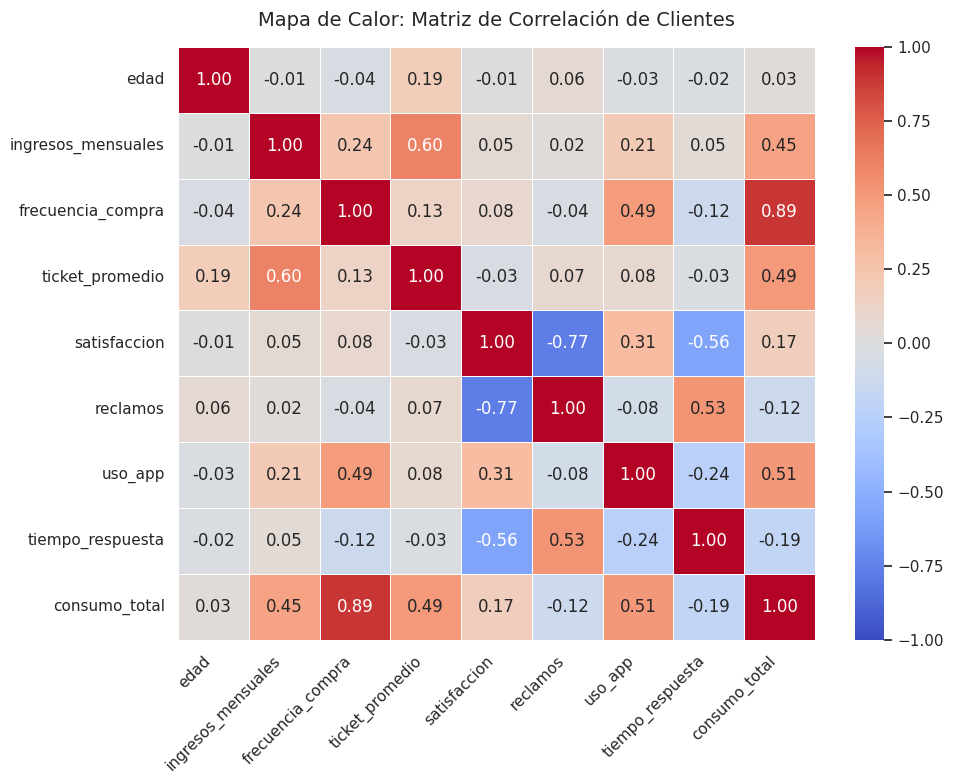

In [12]:
# Mapa de Calor
sns.set_theme(style='white')
fig, ax = plt.subplots(figsize=(10, 8))

sns.heatmap(
    matriz_correlacion,
    annot=True,          # Muestra los valores numéricos dentro de cada cuadro
    cmap='coolwarm',     # Escala bicolor: Azul (Negativo), Blanco (Cero), Rojo (Positivo)
    fmt=".2f",           # Formato con dos decimales
    linewidths=0.5,      # Línea delgada de separación entre cuadros
    vmin=-1, vmax=1,     # Límites estandarizados del coeficiente de Pearson
    ax=ax
)

# Configuración de etiquetas y títulos para evitar que se corten
ax.set_title('Mapa de Calor: Matriz de Correlación de Clientes', fontsize=14, pad=15)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()

# Guardar el gráfico en tu computadora
plt.savefig('mapa_calor_correlacion.png', dpi=300)
print("\n Gráfico guardado exitosamente como 'mapa_calor_correlacion.png'")